## Topic 1: What is Overfitting in Neural Networks?

### 1. Introduction
**Overfitting** happens when your neural network learns the training data too well – including its noise and random fluctuations – but fails to perform well on new, unseen data.

**Real-life use:** Imagine a student memorizing exam answers without understanding concepts. They ace the practice test (training data) but fail the real exam (new data). Overfitting is exactly this problem in machine learning.

### 2. Detailed Explanation

#### What happens during overfitting?
- The model captures not just the real pattern, but also random "noise" in the training data
- Training performance is excellent (very low error)
- Validation/test performance is poor (high error)
- There is a **large gap** between training and validation metrics

#### How to detect overfitting?
Train your model and monitor both:
- **Training loss/accuracy** – how well it learns the training data
- **Validation loss/accuracy** – how well it generalizes to new data

**Warning signs:**
- Training error keeps decreasing
- Validation error stops decreasing or starts increasing
- The gap between training and validation keeps growing

#### Visual example from the transcript:
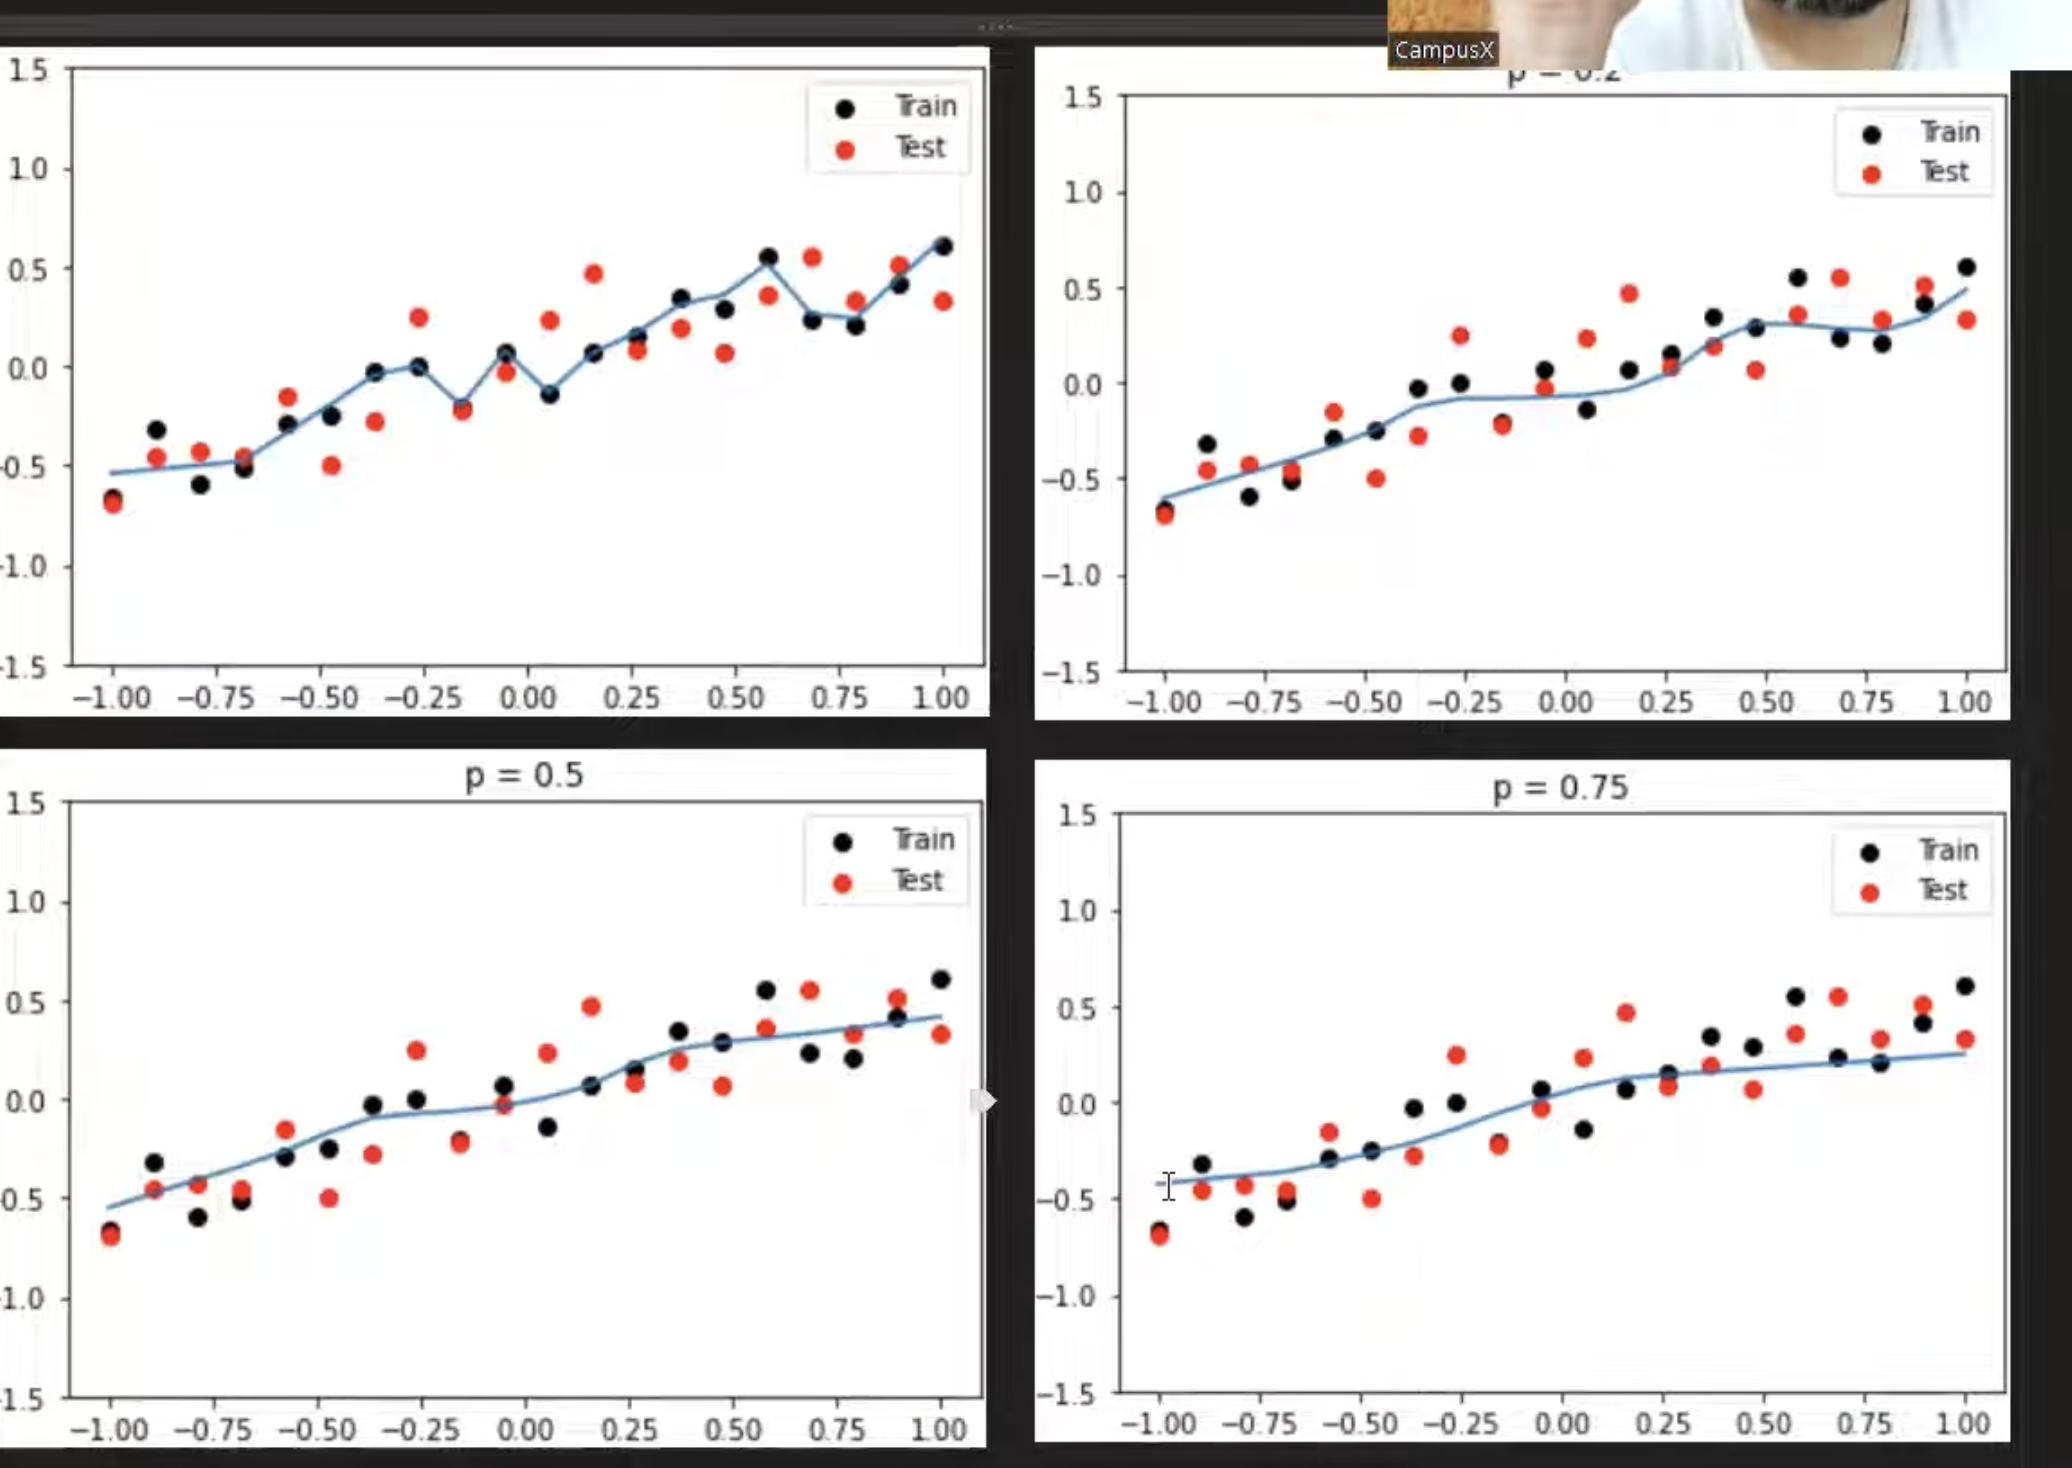

In regression: The model creates a very jagged, complex line that passes through *every* training point but fails to capture the true smooth relationship.
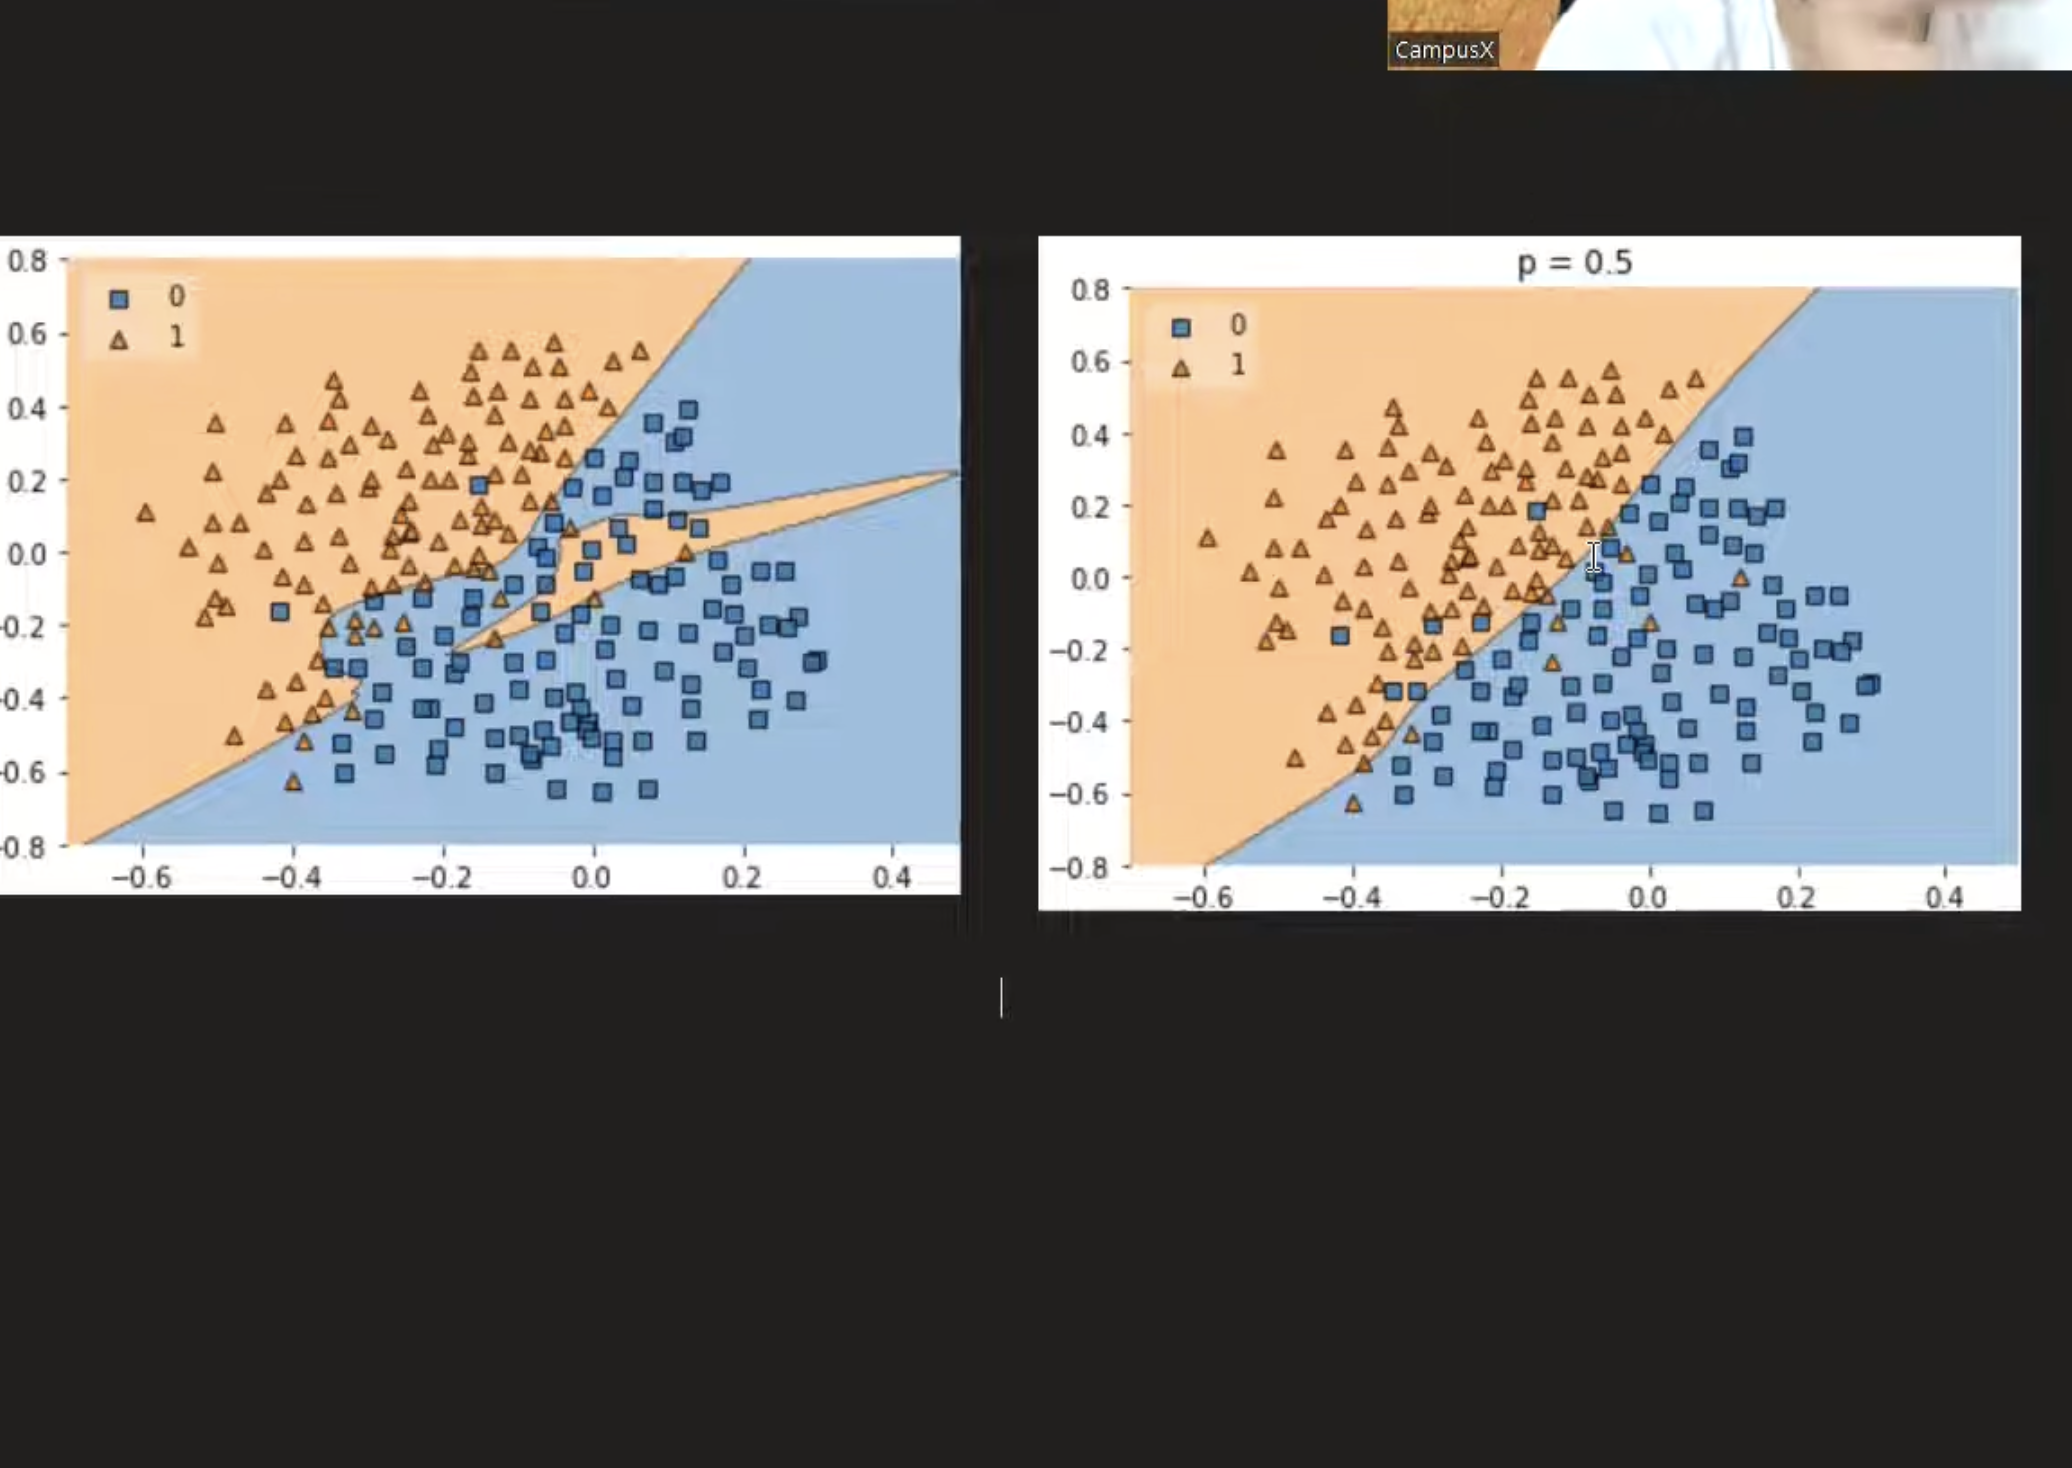
In classification: The decision boundary becomes extremely wiggly, creating small "islands" of one class inside another class's territory.

### 3. Key Points

| Concept | Explanation |
|---------|-------------|
| **Overfitting** | Model memorizes instead of learns |
| **Underfitting** | Model is too simple, fails to capture patterns |
| **Generalization** | Model's ability to perform on new data |
| **Training vs Validation gap** | Big gap = likely overfitting |

### 4. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|---------------|
| Only looking at training accuracy | Hides overfitting completely | Always check validation metrics |
| Ignoring the training-validation gap | Even small gaps can indicate issues | Plot both curves together |
| Thinking complex model = better model | Complex models are more prone to overfitting | Start simple, increase complexity only if needed |

### 5. Interview/Exam Questions

**Q1: How can you tell if your model is overfitting?**
*Answer:* When training performance is significantly better than validation/test performance. The model works great on data it has seen but poorly on new data.

**Q2: What's the difference between overfitting and underfitting?**
*Answer:* Overfitting = too complex, memorizes noise. Underfitting = too simple, misses patterns. Overfitting has low training error but high validation error. Underfitting has high error everywhere.

### 6. Revision Notes

- ✅ Overfitting = model learns noise, not signal
- ✅ Key sign: large gap between training and validation performance
- ✅ Affects both regression and classification problems
- ✅ Prevention techniques include **Dropout** (next topic)
- ✅ Always validate on unseen data to detect overfitting

---



## Topic 2: Dropout Layers – Concept and Purpose

### 1. Introduction

**Dropout** is a regularization technique that prevents overfitting in neural networks. It works by randomly "turning off" (dropping out) a percentage of neurons during training.

**Real-life use:** Think of a sports team where the coach randomly benches different players during practice. No single player becomes too essential – everyone learns to work independently. Similarly, dropout forces the neural network to not rely too heavily on any single neuron, making the overall model more robust.

### 2. Detailed Explanation

#### How Dropout Works

During **each training batch**:
- A random subset of neurons is temporarily removed
- The percentage removed is called the **dropout rate** (e.g., 0.2 = 20%)
- The network must learn to make predictions with the remaining neurons
- Next batch: a *different* random subset is dropped

#### Why Dropout Prevents Overfitting

| Problem Dropout Solves | How Dropout Fixes It |
|------------------------|----------------------|
| Neurons co-adapting too much | Forces neurons to work independently |
| Model becomes too complex | Simpler, more general patterns emerge |
| Memorizing noise | Can't rely on specific neuron combinations |

#### Effect on Model Behavior

**Without Dropout (Overfitting):**
- Decision boundary is jagged and wiggly
- Model is too "sensitive" to small data changes
- Great on training, poor on validation

**With Dropout (Regularized):**
- Decision boundary becomes smoother
- Model generalizes better
- Gap between training and validation reduces

#### Dropout Rate Range

| Dropout Rate | Effect |
|--------------|--------|
| Too low (e.g., 0.1) | Little effect, still overfits |
| Sweet spot (e.g., 0.5) | Good regularization |
| Too high (e.g., 0.8) | May cause underfitting |

**From the transcript:** Rate 0.2 (20%) showed some improvement, rate 0.5 gave smooth decision boundary, rate 0.8 caused underfitting.

### 3. Key Points

- ✅ Dropout = randomly disabling neurons during training
- ✅ Only active during **training** – turned off during prediction/testing
- ✅ Dropout rate = fraction of neurons dropped (typical: 0.2 to 0.5)
- ✅ Makes decision boundaries smoother and less sensitive
- ✅ One of the most effective regularization techniques for neural networks

### 4. Common Mistakes

| Mistake | Explanation | Fix |
|---------|-------------|-----|
| Using dropout during testing | This would add random noise to predictions | Dropout is TRAINING only |
| Setting rate too high (0.8+) | Model becomes too weak, underfits | Start with 0.5, adjust up/down |
| Setting rate too low (0.1) | Little regularization effect | Increase gradually |
| Placing dropout incorrectly | Putting it after the last layer can mute outputs | Place between hidden layers |

### 5. Interview/Exam Questions

**Q1: What does the dropout rate parameter mean?**
*Answer:* It specifies the fraction of neurons randomly dropped during each training update. For example, rate 0.2 means 20% of neurons are temporarily removed from the network.

**Q2: Why does dropout help with overfitting?**
*Answer:* Dropout prevents neurons from co-adapting too much. The network cannot rely on specific neurons or combinations, so each neuron learns more robust, independent features. This leads to better generalization.

**Q3: Is dropout used during inference/prediction?**
*Answer:* No. Dropout is only applied during training. During prediction, all neurons are active (often with scaling to account for dropout during training).

### 6. Revision Notes

- 🔘 **Dropout** = regularization for neural networks
- 🔘 Randomly drops neurons during training
- 🔘 Rate 0.2–0.5 works best (experiment to find sweet spot)
- 🔘 Produces smoother decision boundaries
- 🔘 Reduces the training-validation performance gap
- 🔘 Training only – NOT used during testing

---


## Topic 3: Dropout Implementation – Regression Problem Example

### 1. Introduction

This topic shows how to apply dropout to a **regression problem** – where we predict a continuous value (like price, temperature, or a trend line). The transcript demonstrates comparing two identical neural networks: one without dropout, one with dropout.

**Real-life use:** Predicting house prices, stock values, temperature, or any numerical output. Dropout helps prevent the model from overfitting to noise in the training data.

### 2. Detailed Explanation

#### The Problem Setup

The data has an **input** (feature) and **output** (target) with a non-linear relationship. The goal is to find a line/curve that captures the true pattern.

#### Architecture Used (Same for Both Models)

| Layer Type | Details |
|------------|---------|
| Input layer | Takes the feature(s) |
| Hidden layer | 128 neurons, activation function applied |
| Output layer | Single neuron (for regression) |

**Training settings:**
- Optimizer: Adam
- Learning rate: fixed value
- Loss function: MSE (Mean Squared Error)

#### Model 1: Without Dropout (Baseline)

When trained on the data:
- Training error: Very low (approximately 0.03)
- Validation error: Much higher (approximately 0.20)
- **Result:** Large gap → Overfitting

The plotted regression line becomes extremely jagged, trying to pass through every training point instead of following the smooth underlying pattern.

#### Model 2: With Dropout

**Changes made:**
- Added dropout layer **after the input layer**
- Added dropout layer **after the hidden layer**
- Dropout rate: 0.2 (20%)

**Results:**
- Training error increased slightly (now around 0.05)
- Validation error decreased significantly (now around 0.12)
- **Result:** Smaller gap → Overfitting reduced

The regression line becomes much smoother – the model no longer tries to capture every tiny fluctuation in the training data.

### 3. Key Points

| Metric | Without Dropout | With Dropout (0.2) |
|--------|-----------------|-------------------|
| Training error | Very low (~0.03) | Slightly higher (~0.05) |
| Validation error | High (~0.20) | Lower (~0.12) |
| Gap | Large | Reduced |
| Decision boundary | Jagged, wiggly | Smooth |
| Overfitting | Present | Reduced |

### 4. Syntax/Structure (Dropout Placement)

```
Model Architecture with Dropout:
├── Input Layer
├── Dropout Layer (rate = 0.2)    ← After input
├── Hidden Layer (128 neurons)
├── Dropout Layer (rate = 0.2)    ← After hidden
└── Output Layer (1 neuron)
```

### 5. Code Example (Conceptual)

```python
# Model WITHOUT dropout (overfits)
model_without_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(1)  # Output layer for regression
])

# Model WITH dropout (regularized)
model_with_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),  # 20% neurons dropped after hidden layer
    Dense(1)
])

# Or with dropout after input as well:
model_with_two_dropouts = Sequential([
    Dropout(0.2),  # After input
    Dense(128, activation='relu'),
    Dropout(0.2),  # After hidden
    Dense(1)
])

# Compile both the same way
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
```

### 6. Output Visualization (What You See)

**Plot without dropout:**
- Jagged, wiggly line that passes through almost every black training point
- Red test points are poorly predicted
- Line looks like it's "chasing" the noise

**Plot with dropout (rate 0.2):**
- Smooth curve that follows the general trend
- Still passes near training points but doesn't chase every fluctuation
- Both training and test points are reasonably well predicted

### 7. Common Mistakes

| Mistake | Why Problematic | Correct Approach |
|---------|-----------------|------------------|
| Placing dropout ONLY after output layer | Dropout after output "mutes" predictions without benefit | Place between hidden layers |
| Using same rate for all layers | Different layers may need different regularization | Experiment; start with 0.2-0.5 |
| Not comparing baseline vs dropout model | Can't tell if dropout actually helped | Always train both versions |

### 8. Interview/Exam Questions

**Q1: In the regression example, what changed when dropout was added?**
*Answer:* Training error increased slightly (which is expected), but validation error decreased significantly, and the gap between them reduced. The regression line became smoother.

**Q2: Why did training error INCREASE with dropout?**
*Answer:* Because dropout makes the task harder – the network has fewer neurons available during each training step. This is intentional. A slightly higher training error is acceptable if validation error improves.

**Q3: What dropout rate was used first in the regression example? What happened?**
*Answer:* Rate 0.2 (20%) was used first. It reduced overfitting but didn't eliminate it completely. Rate 0.5 gave an even smoother result.

### 9. Revision Notes

- 📊 **Regression** = predicting continuous numbers
- 📊 **Baseline** (no dropout): low training error, high validation error = overfitting
- 📊 **With dropout (0.2)**: training error up slightly, validation error down significantly
- 📊 **Result**: smoother curve, reduced overfitting
- 📊 **Placement**: after input layer AND after hidden layers (not after output)
- 📊 Always compare dropout vs non-dropout to verify improvement

---



## Topic 4: Dropout Implementation – Classification Problem Example

### 1. Introduction

This topic shows how to apply dropout to a **classification problem** – where we predict which category/class a data point belongs to. The transcript demonstrates a binary classification problem with two input features and one output (class 0 or class 1).

**Real-life use:** Spam detection (spam/not spam), medical diagnosis (disease/no disease), image recognition (cat/dog), customer churn prediction (will leave/won't leave).

### 2. Detailed Explanation

#### The Problem Setup

The data has two input columns (features) and one output column (class label). The data is **non-linearly separable** – meaning you can't draw a straight line to separate the two classes.

**Data visualization:** Two classes (orange and blue) are mixed in a pattern – some points of one class appear inside the region of the other class.

#### Architecture Used

| Layer Type | Classification | Regression (from previous) |
|------------|----------------|---------------------------|
| Input layer | 2 features | 1 or more features |
| Hidden layer | 128 neurons (same) | 128 neurons |
| Output layer | 1 neuron | 1 neuron |
| Output activation | **Sigmoid** (for probability) | Linear (no activation) |
| Loss function | Binary crossentropy | MSE |

#### Results Without Dropout

When trained for 500 epochs:
- **Training accuracy:** ~92%
- **Validation accuracy:** ~74%
- **Gap:** 18% → Clear overfitting

**Decision boundary visualization:**
- Extremely wiggly and complex
- Creates small "islands" – blue points making tiny orange regions and vice versa
- The boundary tries to capture every single point's location
- Will perform poorly on new data

#### Results With Dropout

**First attempt (dropout rate 0.2):**
- Improvement was small – still some overfitting

**Second attempt (dropout rate 0.5):**
- Much smoother decision boundary
- Clear separation line emerges
- No small "islands" or wiggly regions

**Final validation accuracy improved** – stopped at higher accuracy (was stuck at ~72%, improved meaningfully)

### 3. Key Points

| Metric | Without Dropout | With Dropout (0.5) |
|--------|-----------------|-------------------|
| Training accuracy | ~92% | Slightly lower |
| Validation accuracy | ~74% | Improved |
| Decision boundary | Wiggly with "islands" | Smooth and clean |
| Generalization | Poor | Good |

### 4. Syntax/Structure (Classification Model)

```
Classification Model Architecture:
├── Input Layer (2 features)
├── Dense Hidden Layer (128 neurons, activation='relu')
├── Dropout Layer (rate = 0.2 or 0.5)
├── Output Layer (1 neuron, activation='sigmoid')
└── Loss = 'binary_crossentropy'
```

### 5. Code Example (Conceptual)

```python
# Classification model WITHOUT dropout (overfits)
model_no_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),  # 2 input features
    Dense(1, activation='sigmoid')  # Sigmoid for probability output
])

model_no_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classification model WITH dropout
model_with_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dropout(0.5),  # 50% dropout after hidden layer
    Dense(1, activation='sigmoid')
])

model_with_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training both for comparison
history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=500, validation_data=(X_val, y_val))
history_with_dropout = model_with_dropout.fit(X_train, y_train, epochs=500, validation_data=(X_val, y_val))
```

### 6. Output Visualization (What You See)

**Decision boundary WITHOUT dropout:**
- Very complex, wiggly line
- Creates tiny "enclaves" – e.g., a blue dot completely surrounded by orange region but classified as blue (overfitting to that single point)
- Looks like a messy scribble

**Decision boundary WITH dropout (rate 0.2):**
- Still some wiggles, but improved

**Decision boundary WITH dropout (rate 0.5):**
- Very smooth, clean line
- No tiny islands
- Boundary follows the TRUE underlying pattern of the data

### 7. Common Mistakes

| Mistake | Problem | Correct Way |
|---------|---------|-------------|
| Using linear activation for classification | Output won't be a valid probability (0-1) | Use sigmoid for binary, softmax for multi-class |
| Not scaling dropout rate for classification | May need different rate than regression | Experiment; classification often needs higher rates (0.5) |
| Only looking at training accuracy | Hides overfitting | Always track validation accuracy |

### 8. Interview/Exam Questions

**Q1: What activation function is used in the output layer for binary classification, and why?**
*Answer:* Sigmoid activation, because it squashes the output to a value between 0 and 1, which can be interpreted as probability of belonging to class 1.

**Q2: In the classification example, what dropout rate finally produced a good, smooth decision boundary?**
*Answer:* Dropout rate 0.5 (50%) produced a very smooth decision boundary with no small "islands" and good separation.

**Q3: What visual sign indicated overfitting in the classification problem?**
*Answer:* The decision boundary had many small "islands" where isolated points of one class created tiny regions inside the other class's territory. It was too wiggly and complex.

### 9. Revision Notes

- 🏷️ **Classification** = predicting categories (not numbers)
- 🏷️ Output activation: **sigmoid** (binary) or **softmax** (multi-class)
- 🏷️ Loss function: **binary_crossentropy** (not MSE)
- 🏷️ Without dropout: wiggly boundary with "islands" = overfitting
- 🏷️ With dropout 0.2: some improvement
- 🏷️ With dropout 0.5: smooth, clean boundary, good generalization
- 🏷️ Classification may need **higher dropout rates** than regression

---


## Topic 5: Dropout Rate Tuning – Finding the Sweet Spot

### 1. Introduction

Choosing the right **dropout rate** is critical. Too low, and you still overfit. Too high, and you underfit (model becomes too weak to learn patterns). The transcript demonstrates this trade-off clearly across both regression and classification examples.

**Real-life use:** Like adjusting the heat while cooking – too low and food is raw (underfitting), too high and it burns (overfitting). The "sweet spot" gives perfect results.

### 2. Detailed Explanation

#### The Effect of Different Dropout Rates

| Dropout Rate | Effect | What Happens |
|--------------|--------|--------------|
| **0.0 (no dropout)** | Overfitting | Large training-validation gap, jagged boundaries |
| **0.2 (low)** | Some improvement | Gap reduces, but may still overfit |
| **0.5 (medium)** | Sweet spot often | Smooth boundaries, good generalization |
| **0.8 (high)** | Underfitting | Model too weak, poor performance overall |

#### Regression Example Results

| Dropout Rate | Observation |
|--------------|-------------|
| None (0.0) | Very jagged line, high validation error (~0.20) |
| 0.2 | Smoother line, validation error reduced to ~0.12 |
| 0.5 | Even smoother line, better generalization |
| 0.8 | Too smooth, started underfitting |

#### Classification Example Results

| Dropout Rate | Decision Boundary | Performance |
|--------------|-------------------|-------------|
| None (0.0) | Very wiggly with "islands" | Validation ~72%, large gap |
| 0.2 | Still somewhat wiggly | Minor improvement |
| 0.5 | Smooth, clean line | Best generalization |
| Higher | Too simple | Underfitting |

#### What Happens at the "Sweet Spot" (e.g., 0.5)

- Decision boundary becomes **smooth**
- No small "islands" or wiggly regions
- Clear separation between classes
- Gap between training and validation is minimal

### 3. Key Points

| Rule | Explanation |
|------|-------------|
| **Increase dropout** | If you see overfitting (large gap) |
| **Decrease dropout** | If you see underfitting (poor performance everywhere) |
| **Start at 0.2-0.5** | A reasonable starting range |
| **Experiment** | There's no single perfect rate for all problems |

### 4. Syntax/Structure (Tuning Approach)

```
Tuning Process:
1. Start with no dropout → Confirm overfitting exists
2. Add dropout with rate 0.2 → Check if gap reduced
3. Increase to 0.5 → Check if boundary smooths out
4. If still overfitting → Increase further
5. If underfitting → Decrease rate
```

### 5. Code Example (Experimentation)

```python
# Experiment with different dropout rates
dropout_rates = [0.0, 0.2, 0.5, 0.8]

for rate in dropout_rates:
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(rate),
        Dense(1, activation='sigmoid')  # for classification
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val))
    
    print(f"Dropout rate: {rate}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print("-" * 30)

# Expected pattern:
# rate 0.0 → high training, lower validation (overfit)
# rate 0.2 → gap reduces
# rate 0.5 → best validation performance, smooth boundary
# rate 0.8 → both training and validation lower (underfit)
```

### 6. Output Visualization (Progression)

**Rate 0.0:** `~~~~~wiggly~jagged~boundary~~~~~` (overfit)

**Rate 0.2:** `~~~somewhat~smoother~~~` (better)

**Rate 0.5:** `_____nice_and_smooth_____` (sweet spot)

**Rate 0.8:** `_________too_simple_________` (underfit)

### 7. Common Mistakes

| Mistake | Why Wrong | Correct Approach |
|---------|-----------|------------------|
| Using the same rate for all problems | Different data needs different regularization | Experiment per problem |
| Starting with too high a rate | May underfit from the start | Start low (0.2), increase gradually |
| Not comparing multiple rates | Can't find the sweet spot | Test at least 3-4 different rates |
| Changing other variables while tuning rate | Can't isolate dropout's effect | Keep architecture, learning rate, epochs constant |

### 8. Interview/Exam Questions

**Q1: If your model is overfitting, should you increase or decrease the dropout rate?**
*Answer:* Increase the dropout rate. A higher rate drops more neurons, forcing the network to be more robust and reducing overfitting.

**Q2: What happens if you set the dropout rate too high (e.g., 0.9)?**
*Answer:* The model will likely underfit. Too many neurons are dropped during each training step, so the network can't learn the underlying patterns effectively.

**Q3: In the transcript's examples, what dropout rate worked best for regression? For classification?**
*Answer:* For regression, 0.5 gave a very smooth result. For classification, 0.5 also produced the clean, smooth decision boundary without small "islands."

**Q4: Should you always use the same dropout rate for all layers?**
*Answer:* Not necessarily. Different layers may benefit from different rates. For example, you might use a lower rate on early layers and higher rate on later layers. Start with the same rate and experiment.

### 9. Revision Notes

- 🎯 **Sweet spot** = dropout rate that reduces overfitting without causing underfitting
- 🎯 **Too low (0.2)** → may still overfit
- 🎯 **Just right (0.5)** → smooth, generalizes well
- 🎯 **Too high (0.8+)** → underfitting
- 🎯 **Rule:** Overfitting? → Increase dropout rate
- 🎯 **Rule:** Underfitting? → Decrease dropout rate
- 🎯 Always **experiment** – no universal perfect rate
- 🎯 Plot decision boundaries to visualize the effect

---



## Topic 6: Practical Tips for Using Dropout

### 1. Introduction

Based on practical experience (shared in the transcript), here are actionable tips for effectively using dropout in your neural networks. These guidelines help you avoid common pitfalls and get better results faster.

**Real-life use:** These tips save time and frustration when building real-world models – whether for work, research, or personal projects.

### 2. Detailed Explanation

#### Tip 1: Confirm Overfitting First

**Before adding dropout, verify that overfitting is actually your problem:**

| Check | What to Look For |
|-------|------------------|
| Training vs validation loss | Validation loss stops decreasing or increases |
| Training vs validation accuracy | Large gap between them |
| Decision boundary (if visualizable) | Too wiggly, jagged, or has "islands" |

**Don't add dropout if:** Your model is already underfitting (poor performance everywhere).

#### Tip 2: Start from the Last Layer

**Recommended approach:**
1. Add dropout **after the last hidden layer** first
2. Test if this helps
3. If still overfitting, add dropout after earlier layers

**Why start from the end:** The later layers are typically where overfitting happens most. They have learned high-level features specific to your training data.

#### Tip 3: Increase Dropout for Overfitting, Decrease for Underfitting

| Situation | Action |
|-----------|--------|
| Large training-validation gap | **Increase** dropout rate |
| Poor validation AND training | **Decrease** dropout rate (or remove it) |
| Validation accuracy plateaus too low | Try reducing dropout |

#### Tip 4: Triangulate with Regularization

Dropout is a form of **regularization** (techniques that prevent overfitting). Other regularization methods include:
- L1/L2 regularization
- Early stopping
- Data augmentation
- Reducing model size

**Tip:** Combine dropout with other regularization methods if needed, but start with dropout alone to understand its effect.

#### Tip 5: Typical Starting Points

| Scenario | Suggested Starting Dropout Rate |
|----------|-------------------------------|
| Small dataset (< 10k samples) | 0.3 – 0.5 |
| Large dataset (> 100k samples) | 0.1 – 0.3 |
| Very deep network (> 5 layers) | 0.5 at later layers |
| Classification problems | Try 0.5 first |
| Regression problems | Try 0.2 – 0.5 |

#### Tip 6: Don't Put Dropout After the Output Layer

**Placement rules:**
- ✅ After input layer (optional)
- ✅ After hidden layers (good)
- ❌ After output layer (bad – mutes predictions)

### 3. Key Points

| Tip | Summary |
|-----|---------|
| 1 | Confirm overfitting exists BEFORE adding dropout |
| 2 | Start adding dropout from the last hidden layer |
| 3 | Increase rate for overfitting, decrease for underfitting |
| 4 | Dropout = one form of regularization |
| 5 | Start with 0.2-0.5 depending on dataset size and problem type |
| 6 | Never place dropout after output layer |

### 4. Code Example (Applying All Tips)

```python
# Tip 1: First build a baseline WITHOUT dropout to confirm overfitting
baseline_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
# Train and check validation performance
# If validation is much worse than training → OVERFITTING confirmed

# Tip 2 & 5: Start with dropout after last hidden layer, rate based on problem
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dropout(0.5),  # ← Start here (rate 0.5 for classification)
    Dense(1, activation='sigmoid')
])

# Tip 3: If still overfitting, increase rate
model_with_more_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dropout(0.7),  # Increased from 0.5
    Dense(1, activation='sigmoid')
])

# Tip 6: WRONG placement (don't do this)
bad_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid'),
    Dropout(0.5)  # ❌ After output layer - mutes predictions!
])
```

### 5. Common Mistakes (Reinforced)

| Mistake | Why It's Wrong |
|---------|-----------------|
| Adding dropout "just in case" | May hide whether overfitting was actually the problem |
| Placing dropout after output layer | Output gets "muted" – poor predictions |
| Changing dropout rate AND other hyperparameters together | Can't tell what caused improvement/worsening |
| Using dropout when model is underfitting | Makes an already weak model even weaker |

### 6. Interview/Exam Questions

**Q1: What is the first step you should take before using dropout?**
*Answer:* Build a baseline model without dropout to confirm that overfitting is actually happening. Compare training and validation metrics – if there's a large gap, overfitting is confirmed.

**Q2: Where should you start when adding dropout to an architecture?**
*Answer:* Start by adding dropout after the last hidden layer. If that helps but overfitting persists, add dropout after earlier layers as well.

**Q3: Is dropout the only way to regularize a neural network?**
*Answer:* No. Dropout is one form of regularization. Others include L1/L2 regularization, early stopping, data augmentation, and reducing model size.

**Q4: What does "triangulate" mean in the context of using dropout?**
*Answer:* It means experimenting systematically – changing one thing at a time (like dropout rate or placement) while keeping everything else constant – to find what works best for your specific problem.

### 7. Revision Notes

- 🔍 **First step:** Confirm overfitting with a baseline model
- 🎯 **Placement:** Start from the last hidden layer
- 📈 **Overfitting?** → Increase dropout rate
- 📉 **Underfitting?** → Decrease dropout rate
- 🏁 **Typical start:** 0.2 (regression) or 0.5 (classification)
- 🧪 **Experiment:** Change one variable at a time
- ❌ **Never:** Put dropout after output layer
- 🔧 **Dropout = regularization** – there are other methods too

---


## Topic 7: Challenges and Limitations of Dropout

### 1. Introduction

While dropout is highly effective, it comes with certain **challenges and limitations** you need to be aware of. Understanding these helps you anticipate problems and decide when dropout is (or isn't) the right solution.

**Real-life use:** When building production models, knowing the trade-offs helps you debug issues and set realistic expectations.

### 2. Detailed Explanation

#### Challenge 1: Slower Convergence

**What does convergence mean?**
Convergence is when the neural network's error stops decreasing significantly – it has "learned" as much as it can.

**How dropout affects convergence:**
- Without dropout: Network converges faster
- With dropout: Convergence becomes **slower**

**Why this happens:**
Each training step uses a different random subset of neurons. The network can't rely on specific pathways, so it takes more iterations to learn stable patterns.

#### Challenge 2: Changes to the Loss/Cost Function

**What changes?**
When you use dropout, your **loss function value changes** compared to the same network without dropout.

**Why this matters:**
- You cannot directly compare loss values between dropout and non-dropout models
- The "baseline" is different because dropout randomly removes neurons
- Loss calculations are done on a "thinned" network

**Think of it like:**
Measuring team performance with 11 players vs 9 players. The numbers will be different even if the players are equally skilled.

#### Challenge 3: Gradient Calculation Becomes More Difficult

**What are gradients?**
Gradients tell the network how much to adjust each neuron's weight during training (the "learning signal").

**The problem with dropout:**
- Gradients are calculated on different neuron subsets each time
- The optimization path becomes less stable
- Can sometimes cause training difficulties

**Analogy:** Like trying to navigate a city where different roads are closed at random each day – you'll still get there, but it's more challenging.

#### Challenge 4: Not a Magic Solution

Dropout helps with overfitting, but it won't fix:
- Poor data quality
- Wrong architecture choice
- Incorrect learning rate
- Insufficient data (sometimes)

### 3. Key Points

| Challenge | Description |
|-----------|-------------|
| **Slower convergence** | Takes more training iterations to reach good performance |
| **Changed loss values** | Cannot directly compare loss with non-dropout models |
| **Difficult gradients** | Optimization becomes less stable |
| **No cure-all** | Won't fix other problems like bad data or wrong architecture |

### 4. Common Mistakes

| Mistake | Why Problematic | Better Approach |
|---------|-----------------|-----------------|
| Comparing loss values directly across dropout/non-dropout | Different "baselines" make comparison invalid | Compare validation accuracy/error instead |
| Giving up because training is slow | Slower convergence is EXPECTED with dropout | Train for more epochs |
| Using dropout to fix non-overfitting problems | Won't help underfitting or data issues | Diagnose the real problem first |

### 5. Interview/Exam Questions

**Q1: What does "convergence" mean, and how does dropout affect it?**
*Answer:* Convergence is when the neural network's error stabilizes at a minimum. Dropout slows down convergence because the network must learn robust patterns using different random subsets of neurons each iteration. Training takes more epochs.

**Q2: Why can't you directly compare loss values between a model with dropout and one without?**
*Answer:* Dropout randomly removes neurons during training, so loss is calculated on a "thinned" network. This changes the loss function's baseline, making direct comparison invalid. Instead, compare validation metrics like accuracy or error on test data.

**Q3: If dropout slows down training, should you avoid using it?**
*Answer:* No. The benefits (reduced overfitting, better generalization) usually outweigh the cost of slower training. You can compensate by training for more epochs or using a slightly larger learning rate.

**Q4: Will dropout fix ALL overfitting problems?**
*Answer:* No. Dropout is effective but not magical. If overfitting is extreme (very small dataset, extremely large model), you may need additional techniques like data augmentation, model size reduction, or other regularization methods.

### 6. Revision Notes

- 🐢 **Slower convergence** – expected, train longer
- 📊 **Loss values change** – don't compare directly with non-dropout
- ⛰️ **Gradients harder** – optimization less stable
- 🔧 **Not a cure-all** – fix data/architecture problems first
- ✅ **Still worth it** – benefits of reduced overfitting outweigh challenges
- 🧠 **Understanding trade-offs** helps you debug and set expectations

### Summary Table: With vs Without Dropout

| Aspect | Without Dropout | With Dropout |
|--------|-----------------|--------------|
| Convergence speed | Faster | Slower |
| Loss value meaning | Standard baseline | Different baseline |
| Overfitting risk | Higher | Lower |
| Training stability | More stable | Less stable |
| Generalization | Often worse | Usually better |

---


## Topic 8: Dropout – Mathematical Intuition and Further Learning

### 1. Introduction

While the transcript doesn't provide deep mathematical derivations, it mentions that dropout has a mathematical foundation involving **"thinning"** neural networks. This topic summarizes what happens mathematically and provides guidance for deeper study.

**Real-life use:** Understanding the math helps you debug complex models and explains *why* dropout works so effectively.

### 2. Detailed Explanation

#### The Core Mathematical Idea

During training with dropout rate `p`:
- Each neuron is kept with probability `1 - p`
- Each neuron is dropped (set to zero) with probability `p`

**What this means mathematically:**
You are effectively training an **exponential ensemble** of `2^n` different "thinned" networks (where `n` is the number of neurons), all sharing weights.

#### Scaling at Test Time

During prediction/testing:
- No dropout is applied (all neurons active)
- Output weights are scaled by `1 - p` to account for the fact that more neurons are present than during training

**Analogy:** Like averaging the predictions of many different smaller networks that were trained together.

#### Why This Works Mathematically

| Mathematical Concept | Effect |
|---------------------|--------|
| Ensemble averaging | Combining many models reduces variance |
| Weight sharing | All sub-networks learn together efficiently |
| Adaptive regularization | Dropout rate controls the strength |

#### For Deeper Mathematical Understanding

The transcript recommends:
1. Reading the **original research paper** on dropout
2. Understanding how it relates to **L2 regularization** (mathematically similar in some cases)
3. Learning about **batch normalization** as a related technique

### 3. Key Points

- ✅ Dropout = training an ensemble of thinned networks
- ✅ Test time uses **scaling** to account for dropout
- ✅ Mathematically related to other regularization methods
- ✅ Original paper provides rigorous mathematical treatment

### 4. Further Learning Recommendations (from Transcript)

| Resource | What You'll Learn |
|----------|-------------------|
| Original Dropout Research Paper | Mathematical proof, experimental validation |
| L2 Regularization comparison | How dropout relates to weight decay |
| Batch Normalization | Another popular regularization technique |
| Code implementation from scratch | Deep understanding of mechanics |

### 5. Common Mistakes

| Mistake | Correct Understanding |
|---------|----------------------|
| Thinking dropout is just "random turning off" | It's mathematically grounded as ensemble learning |
| Ignoring the scaling factor at test time | Essential for correct predictions |
| Not reading the original paper | You miss important implementation details |

### 6. Interview/Exam Questions

**Q1: How does dropout relate to ensemble learning mathematically?**
*Answer:* Dropout effectively trains an exponentially large ensemble of "thinned" neural networks that share weights. At test time, using all neurons with appropriate scaling approximates averaging the predictions of all these sub-networks.

**Q2: What happens to the weights at test time when using dropout?**
*Answer:* No dropout is applied (all neurons are active), but the output weights are typically multiplied by the keep probability `(1-p)` to account for the fact that more neurons are present during testing than during any single training step.

**Q3: Where can I learn more about the mathematics of dropout?**
*Answer:* Read the original dropout research paper by Srivastava et al. It explains the mathematical foundations, relationship to other regularization methods, and provides experimental validation.

### 7. Revision Notes

**Quick Summary of Entire Dropout Series:**

| Topic | Key Takeaway |
|-------|--------------|
| Overfitting | Model memorizes noise → large training-validation gap |
| Dropout concept | Randomly disable neurons during training |
| Regression | Smoother curves, reduced overfitting |
| Classification | Clean decision boundaries, no "islands" |
| Rate tuning | 0.2–0.5 typical; increase for overfitting, decrease for underfitting |
| Practical tips | Start from last layer, confirm overfitting first |
| Challenges | Slower convergence, changed loss values |
| Mathematics | Ensemble of thinned networks, test-time scaling |

### Final Checklist Before Using Dropout

- [ ] Confirmed overfitting exists (baseline model)
- [ ] Selected starting dropout rate (0.2–0.5)
- [ ] Placed dropout after hidden layers (not after output)
- [ ] Prepared to train for more epochs
- [ ] Will compare validation metrics, not raw loss values
- [ ] Ready to experiment with different rates

---

**That concludes all topics from the transcript.**

